In [15]:
import pytest
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton as scipy_newton 
from scipy.optimize import bisect

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Usual stopping conditions</b>

<p>
To decide when to terminate the iterations
\(\{x_n\}\), one typically uses one or more of the following
criteria:
</p>

<p><b>1. Successive iterates are close</b></p>

$$
|x_{n+1} - x_n| < \varepsilon.
$$

<p>
This measures the convergence of the sequence \(\{x_n\}\).
</p>

<p><b>2. Function value is small</b></p>

$$
|f(x_{n+1})| < \varepsilon.
$$

<p>
This checks that the current iterate is near a root of \(f\).
</p>

<p><b>3. Maximum number of iterations reached</b></p>

$$
n \geq N_{\max}.
$$

<p>
This acts as a safety cap to prevent infinite or very slow iterations.
</p>

</div>


In [16]:
def stop(x_new, x_old, f, tol=1e-8):
    if abs(x_new - x_old) < tol:
        return True, "Converged: successive iterates close"
    if abs(f(x_new)) < tol:
        return True, "Converged: function value is small"
    return False, ""

In [17]:
def assert_close(a, b, tol=1e-8):
    """
    Since floating point arithmetic introduces rounding error we need to add a tolerance
    """
    if abs(a - b) > tol:
        raise AssertionError(f"{a} is not within {tol} of {b}")

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Newton–Raphson Method</b>

<p>
The Newton–Raphson iteration improves an initial guess \(x_0\) by replacing it with the
x‑intercept of the tangent line to \(f\) at \(x_0\). The formula is
</p>

$$
x_1 = x_0 - \frac{f(x_0)}{f'(x_0)}
$$

<p>
Repeating this process yields the iterative formula
</p>

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}.
$$

</div>



In [31]:
class Newton:
    """
    Newton–Raphson root finder.
    """

    def __init__(self, function, derivative):
        self.f = function
        self.df = derivative
        self.history = None   # will store iterates after solve()

    def iteration(self, x):
        return x - self.f(x) / self.df(x)

    def solve(self, x0, tol=1e-8, max_iter=100):
        xs = [x0] # history includes x0 so plots show the full path from initial guess

        for _ in range(max_iter):
            x_old = xs[-1]
            x_new = self.iteration(x_old)
            
            
            if not np.isfinite(x_new): # Newton can diverge violently, derivative blows up near 0, iterates bounce and hit nan
                self.history = xs
                return {
                    "root": None,
                    "history": xs,
                    "reason": "Failed: iterate diverged (nan or inf)",
                    "iterations": len(xs),
                    "converged": False
                }
            done, reason = stop(x_new, x_old, self.f, tol)
            xs.append(x_new)

            if done:
                self.history = xs
                return {
                    "root": x_new,
                    "history": xs,
                    "reason": reason,
                    "iterations": len(xs)
                }

        self.history = xs
        return {
            "root": xs[-1],
            "history": xs,
            "reason": "Stopped: maximum iterations reached",
            "iterations": len(xs)
        }


    def plot(self, padding=1.0, show_tangents=True):
        if self.history is None:
            raise RuntimeError("Call solve() before plot().")

        xs = np.array(self.history)
        xmin, xmax = xs.min() - padding, xs.max() + padding

        # Smooth curve for f(x)
        X = np.linspace(xmin, xmax, 400)
        Y = self.f(X)

        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='black', linewidth=1)

        # Plot the function
        plt.plot(X, Y, label="f(x)", color="blue")

        # Plot Newton iterates (except x0)
        plt.scatter(xs[1:], self.f(xs[1:]), color="red", zorder=5, label="Newton iterates")

        # Highlight the initial guess x0
        plt.scatter(xs[0], self.f(xs[0]), color="yellow", edgecolor="black",
                    s=120, zorder=6, label="Initial guess")


        # Vertical lines from x-axis to curve
        for x in xs:
            plt.plot([x, x], [0, self.f(x)], color="gray", linestyle="--", linewidth=0.8)
        
        if show_tangents:
            for x in xs[:3]:
                """
                Tangent lines for the first few iterations
                """
                y = self.f(x)
                slope = self.df(x)

                # tangent line: y_t = slope*(t - x) + y
                t = np.linspace(x - 1, x + 1, 50)
                y_t = slope * (t - x) + y

                plt.plot(t, y_t, color="green", alpha=0.2)


        plt.title("Newton's Method Convergence")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

In [32]:
f  = lambda x: x**2 - 2
df = lambda x: 2*x

solver = Newton(f, df)

my_result = solver.solve(x0=1.0)
root      = my_result["root"]
history   = my_result["history"]
reason    = my_result["reason"]
n_it      = my_result["iterations"]


my_root = my_result["root"]
my_iters = my_result["iterations"]


print(root)
print(history)
print(reason)
print(n_it)

1.4142135623746899
[1.0, 1.5, 1.4166666666666667, 1.4142156862745099, 1.4142135623746899]
Converged: function value is small
5


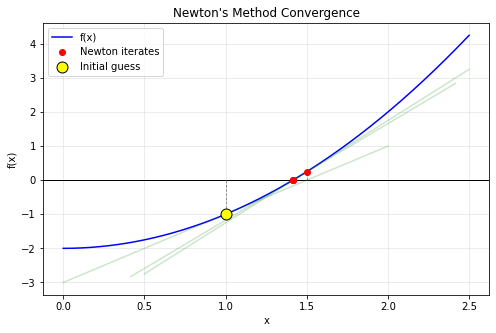

In [33]:
solver.plot()

In [34]:
scipy_root = scipy_newton(f, x0=1.0, fprime=df, tol=1e-8)

In [35]:
print("Newton root from class:", my_root)
print("SciPy Newton root:", scipy_root)

assert_close(my_root, scipy_root, tol=1e-8) #raises AssertionError when isnt close
print("Roots match within tolerance!")

print("Number of computed iterations:", my_iters)

Newton root from class: 1.4142135623746899
SciPy Newton root: 1.4142135623730951
Roots match within tolerance!
Number of computed iterations: 5


In [36]:
f  = lambda x: np.cos(x) - x
df = lambda x: -np.sin(x) - 1

In [37]:
solver = Newton(f, df)
my_result2 = solver.solve(1.0)
my_root2 = my_result2["root"]
history2   = my_result2["history"]
n_it2 = my_result2["iterations"]


print(my_root2)
print(history2)
print(n_it2)

0.739085133385284
[1.0, 0.7503638678402439, 0.7391128909113617, 0.739085133385284]
4


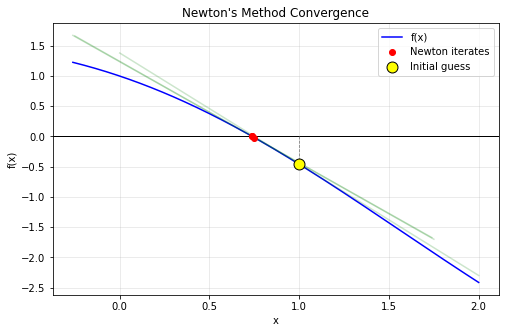

In [38]:
solver.plot()

In [39]:
scipy_root = scipy_newton(f, 1.0, fprime=df)

print(scipy_root)

0.7390851332151607


In [40]:
assert_close(my_root2, scipy_root)
print("Good approximation!")

Good approximation!


In [41]:
f  = lambda x: np.cbrt(x)
df = lambda x: 1/(3 * x**(2/3))

In [42]:
solver = Newton(f, df)
my_result3 = solver.solve(1.0)
my_root3 = my_result3["root"]
history3   = my_result3["history"]
n_it3 = my_result3["iterations"]


print(my_root3)
print(history3)
print(n_it3)

None
[1.0, -2.0]
2


<ipython-input-41-0f101818ba5f>:2: RuntimeWarning: invalid value encountered in double_scalars
  df = lambda x: 1/(3 * x**(2/3))


In [43]:
scipy_root2 = scipy_newton(f, 1.0, fprime=df)

print(scipy_root = scipy_newton(f, 1.0, fprime=df))

<ipython-input-41-0f101818ba5f>:2: RuntimeWarning: invalid value encountered in double_scalars
  df = lambda x: 1/(3 * x**(2/3))


RuntimeError: Failed to converge after 50 iterations, value is nan.

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">


<p>
The function
</p>

$$
f(x) = x^{1/3}, \qquad f'(x) = \frac{1}{3}x^{-2/3}.
$$

<p>
The derivative becomes unbounded as \(x \to 0\), since
</p>

$$
x^{-2/3} \to \infty \quad \Longrightarrow \quad f'(x) \to \infty.
$$

<p>
This violates a key assumption of the Newton–Raphson method: the derivative must be finite and provide a reliable local linear approximation.
</p>

<p>
Starting from \(x_0 = 1\), the first Newton update produces a large jump:
</p>

$$
x_1 = 1 - \frac{1}{\tfrac{1}{3}} = -2.
$$

<p>
Subsequent iterates move closer to the singularity at \(x = 0\). Once an iterate satisfies \(x_n^{-2/3} \approx \infty\), the derivative becomes numerically unstable, and the Newton update
</p>

$$
\frac{f(x_n)}{f'(x_n)}
$$

<p>
produces <code>NaN</code> values. From this point onward, the iteration cannot recover.
</p>

<p>
Hence, Newton’s method is not suitable for functions whose derivatives blow up near the root. The failure arises from the mathematical structure of the function, not from an implementation error.
</p>

</div>



<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Secant Method</b>

<p>
Derivative–free alternative to Newton’s method.  
Instead of using the exact derivative \(f'(x_n)\), it approximates the slope of \(f\) using the most recent two iterates:
</p>

$$
f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}.
$$

<p>
Substituting this finite–difference approximation into the Newton update yields the Secant iteration:
</p>

$$
x_{n+1}
= x_n - f(x_n)\,\frac{x_n - x_{n-1}}{\,f(x_n) - f(x_{n-1})\,}.
$$

<p>
The method requires two initial guesses \(x_0\) and \(x_1\), but no derivative.  
It typically converges faster than other methods, such as bisection, and more robustly than Newton when the derivative is difficult or expensive to compute.
</p>

</div>


In [44]:
class Secant:
    """
    Secant root finder.
    """

    def __init__(self, function):
        self.f = function
        self.history = None   # will store iterates after solve()

    def iteration(self, xn, xn_1):
        f_xn = self.f(xn)
        f_xn1 = self.f(xn_1)

        den = f_xn - f_xn1
        if abs(den) < 1e-14:
            raise ZeroDivisionError("Secant method denominator too small.")

        return xn - f_xn * ((xn - xn_1) / den)



    def solve(self, x1, x0, tol=1e-8, max_iter=100):
        xs = [x0, x1]

        for _ in range(max_iter):
            x_pold = xs[-2]
            x_old = xs[-1]
            x_new = self.iteration(x_old,x_pold)

            done, reason = stop(x_new, x_old, self.f, tol)
            xs.append(x_new)

            if done:
                self.history = xs
                return {
                    "root": x_new,
                    "history": xs,
                    "reason": reason,
                    "iterations": len(xs)
                }

        self.history = xs
        return {
            "root": xs[-1],
            "history": xs,
            "reason": "Stopped: maximum iterations reached",
            "iterations": len(xs)
        }


    def plot(self, padding=1.0, show_secants=True):
        if self.history is None:
            raise RuntimeError("Call solve() before plot().")

        xs = np.array(self.history)
        xmin, xmax = xs.min() - padding, xs.max() + padding

        # Smooth curve for f(x)
        X = np.linspace(xmin, xmax, 400)
        Y = self.f(X)

        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='black', linewidth=1)

        # Plot the function
        plt.plot(X, Y, label="f(x)", color="blue")

        # Plot Secant iterates (except the very first)
        plt.scatter(xs[1:], self.f(xs[1:]), color="red", zorder=5, label="Secant iterates")

        # Highlight the initial guesses
        plt.scatter(xs[0], self.f(xs[0]), color="yellow", edgecolor="black",
                    s=120, zorder=6, label="Initial guess x0")
        plt.scatter(xs[1], self.f(xs[1]), color="orange", edgecolor="black",
                    s=120, zorder=6, label="Initial guess x1")

        # Vertical lines from x-axis to curve
        for x in xs:
            plt.plot([x, x], [0, self.f(x)], color="gray", linestyle="--", linewidth=0.8)

        # Draw secant lines between successive iterates
        if show_secants:
            for i in range(1, len(xs)-1):
                x0, x1 = xs[i-1], xs[i]
                y0, y1 = self.f(x0), self.f(x1)

                # Secant line between (x0, f(x0)) and (x1, f(x1))
                t = np.linspace(min(x0, x1)-1, max(x0, x1)+1, 50)
                # Equation of the secant line
                slope = (y1 - y0) / (x1 - x0)
                y_t = slope * (t - x1) + y1

                plt.plot(t, y_t, color="green", alpha=0.3)

        plt.title("Secant Method Convergence")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

In [45]:
f  = lambda x: np.cbrt(x)

In [46]:
solver = Secant(f)
Secant_Result1 = solver.solve(1.0,-1.0)
Secant_Root1 = Secant_Result1["root"]
Secant_History1 = Secant_Result1["history"]
Secant_n_it1 = Secant_Result1["iterations"]


print(Secant_Root1)
print(Secant_History1)
print(Secant_n_it1)

0.0
[-1.0, 1.0, 0.0]
3


In [20]:
Secantroot_scipy1 = scipy_newton(f, x0=1.0, x1=-1.0)   # secant mode
print(Secantroot_scipy1)

0.0


In [21]:
assert_close(Secant_Root1, Secantroot_scipy1)
print("Good approximation!")

Good approximation!


In [22]:
f = lambda x: x**3
solver = Secant(f)
Secant_Result2 = solver.solve(1.0, 0.5)

Secant_Root2 = Secant_Result2["root"]
Secant_History2 = Secant_Result2["history"]
Secant_n_it2 = Secant_Result2["iterations"]


print(Secant_Root2)
print(Secant_History2)
print(Secant_n_it2)

0.0017292960990730613
[0.5, 1.0, 0.4285714285714286, 0.379746835443038, 0.26813028612560735, 0.20749638938227694, 0.15512529649082862, 0.11753549887397793, 0.088598215217949, 0.06691757670007827, 0.05050390049060238, 0.03812736937342693, 0.028780598243716177, 0.021726092657546017, 0.01640046606736594, 0.012380367642487206, 0.00934565661590561, 0.007054829319857504, 0.0053255325512606005, 0.004020125741105654, 0.003034703091774845, 0.0022908296009423908, 0.0017292960990730613]
23


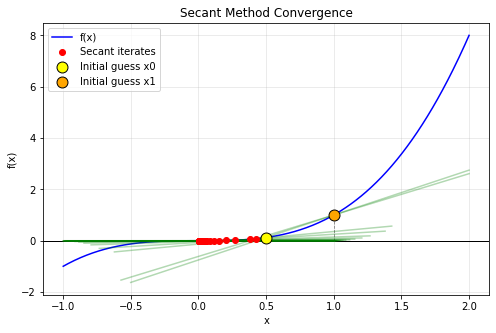

In [23]:
solver.plot()

In [24]:
Secantroot_scipy2 = scipy_newton(f, x0=1.0, x1=0.5)   # secant mode
print(Secantroot_scipy2)
assert_close(Secant_Root1, Secantroot_scipy1)
print("Good approximation!")

RuntimeError: Failed to converge after 50 iterations, value is 4.969241256635084e-07.

In [25]:
f  = lambda x: x**3
df = lambda x: 3*x**2

# Newton test
newton_solver = Newton(f, df)
newton_result = newton_solver.solve(1.0)

# Secant test
secant_solver = Secant(f)
secant_result = secant_solver.solve(1.0, 0.5)

print("Newton root:", newton_result["root"])
print("Newton iterations:", newton_result["iterations"])

print("Secant root:", secant_result["root"])
print("Secant iterations:", secant_result["iterations"])


Newton root: 0.0015224388403474445
Newton iterations: 17
Secant root: 0.0017292960990730613
Secant iterations: 23


<div style="background:#fafafa; padding:10px; border-radius:8px; border:1px solid #ddd; font-size:95%;">
For $$f(x)=x^3$$ the function is extremely flat near the root. Both Newton and Secant satisfy the stopping criterion (small update) long before reaching $$x=0$$, so they “stall’’ around $$10^{-3}$$ even though the true root is zero. This behavior is expected for very flat functions.
</div>



´<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Bisection Method</b>

<p>
A bracketing root–finding method that requires an interval \([a,b]\) with 
\(f(a)\,f(b) < 0\).  
Because the function changes sign on the interval, the Intermediate Value Theorem 
guarantees the existence of a root inside \([a,b]\).
</p>

<p>
At each iteration, the midpoint \(m = \tfrac{a+b}{2}\) is computed.  
If \(f(a)\,f(m) < 0\), the root lies in \([a,m]\); otherwise it lies in \([m,b]\).  
The interval is halved at every step, ensuring steady progress toward the root.
</p>

<p>
Although convergence is only linear and slower than Newton or Secant, the method is 
extremely robust: it <i>always</i> converges as long as the initial interval brackets 
a root.  
For this reason, it is often used as a reliability component inside hybrid methods 
such as Brent’s algorithm.
</p>

</div>

In [26]:
class Bisection:
    """
    Bisection root finder.
    """

    def __init__(self, function):
        self.f = function
        self.history = None

    def solve(self, a, b, tol=1e-8, max_iter=100):
        fa = self.f(a)
        fb = self.f(b)

        if fa * fb > 0:
            raise ValueError("Bisection requires f(a) and f(b) to have opposite signs.")

        xs = []
        x_old = None

        for _ in range(max_iter):
            m = 0.5 * (a + b)
            fm = self.f(m)
            xs.append(m)

            # stopping condition
            if x_old is not None:
                done, reason = stop(m, x_old, self.f, tol)
                if done:
                    self.history = xs
                    return {
                        "root": m,
                        "history": xs,
                        "reason": reason,
                        "iterations": len(xs)
                    }

            # update bracket
            if fa * fm < 0:
                b = m
                fb = fm
            else:
                a = m
                fa = fm

            x_old = m

        self.history = xs
        return {
            "root": xs[-1],
            "history": xs,
            "reason": "Stopped: maximum iterations reached",
            "iterations": len(xs)
        }
    
    def plot(self, padding=1.0):
        if self.history is None:
            raise RuntimeError("Call solve() before plot().")

        xs = np.array(self.history)
        xmin, xmax = xs.min() - padding, xs.max() + padding

        # Smooth curve for f(x)
        X = np.linspace(xmin, xmax, 400)
        Y = self.f(X)

        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='black', linewidth=1)

        # Plot the function
        plt.plot(X, Y, label="f(x)", color="blue")

        # Plot midpoint iterates
        plt.scatter(xs, self.f(xs), color="red", zorder=5, label="Midpoints")

        # Vertical lines showing shrinking intervals
        for x in xs:
            plt.plot([x, x], [0, self.f(x)], color="gray", linestyle="--", linewidth=0.8)

        # Highlight first and last midpoint
        plt.scatter(xs[0], self.f(xs[0]), color="yellow", edgecolor="black",
                    s=120, zorder=6, label="First midpoint")
        plt.scatter(xs[-1], self.f(xs[-1]), color="orange", edgecolor="black",
                    s=120, zorder=6, label="Final midpoint")

        plt.title("Bisection Method Convergence")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

Bisection root: 1.5213797017931938
Newton root: 1.5213797068045676
Secant root: 1.5213797068040897


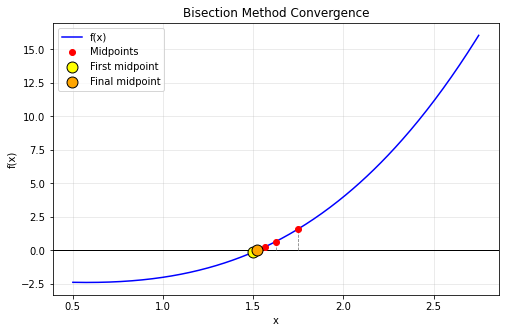

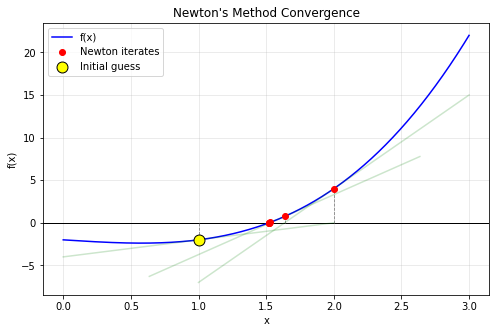

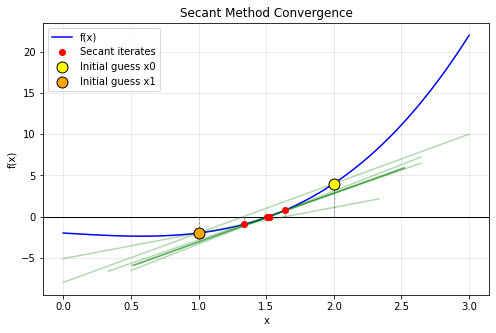

In [27]:
def f(x):
    return x**3 - x - 2

def df(x):
    return 3*x**2 - 1

# Instantiate solvers
bis = Bisection(f)
newt = Newton(f, df)
sec = Secant(f)

# Solve
res_bis = bis.solve(1, 2)
res_newt = newt.solve(1.0)
res_sec = sec.solve(1.0, 2.0)

# Print results
print("Bisection root:", res_bis["root"])
print("Newton root:", res_newt["root"])
print("Secant root:", res_sec["root"])

# Plot
bis.plot()
newt.plot()
sec.plot()

In [28]:
iters_bis = res_bis["iterations"]
iters_newt = res_newt["iterations"]
iters_sec = res_sec["iterations"]

In [29]:
print(f"Bisection number of iterations: {iters_bis:}")
print(f"Newton number of iterations: {iters_newt:}")
print(f"Secant number of iterations: {iters_sec:}")

Bisection number of iterations: 27
Newton number of iterations: 7
Secant number of iterations: 9


In [30]:
root_scipy = bisect(f, 1, 2, xtol=1e-8)
assert_close(res_bis["root"], root_scipy, tol=1e-8)
print("Good approximation!")

Good approximation!


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Brent’s Method</b>

<p>
A hybrid root–finding algorithm that combines the reliability of bisection with the 
speed of interpolation–based methods.  
Brent’s method maintains a bracketing interval \([a,b]\) with \(f(a)\,f(b) < 0\), ensuring 
the root is always trapped.
</p>

<p>
At each iteration, the method attempts an <i>inverse quadratic interpolation</i> step 
(using the last three points), or a <i>secant</i> step when appropriate.  
If the proposed step would leave the bracketing interval or appears numerically unsafe, 
Brent’s method automatically falls back to a bisection step.
</p>

<p>
This adaptive strategy guarantees convergence while achieving superlinear speed when 
the function is smooth.  
It is widely regarded as one of the most robust and efficient derivative–free 
root–finding algorithms.
</p>

</div>

In [31]:
class Brent:
    """
    Brent–Dekker root finder.
    Hybrid of bisection, secant, and inverse quadratic interpolation.
    """

    def __init__(self, function):
        self.f = function
        self.history = None

    def solve(self, a, b, tol=1e-8, max_iter=100):
        fa = self.f(a)
        fb = self.f(b)

        if fa * fb > 0:
            raise ValueError("Brent requires f(a) and f(b) to have opposite signs.")

        # Initialization
        if abs(fa) < abs(fb):
            a, b = b, a
            fa, fb = fb, fa

        c, fc = a, fa
        d = e = b - a

        xs = []
        x_old = None

        for _ in range(max_iter):
            if fb == 0:
                self.history = xs
                return {
                    "root": b,
                    "history": xs,
                    "reason": "Exact root found",
                    "iterations": len(xs)
                }

            # Ensure b is best approximation
            if fa * fb > 0:
                a, fa = c, fc
                d = e = b - a

            if abs(fa) < abs(fb):
                c, b, a = b, a, c
                fc, fb, fa = fb, fa, fc

            # Convergence check
            m = 0.5 * (a - b)
            tol_act = 2 * tol * max(1.0, abs(b))

            xs.append(b)

            if abs(m) <= tol_act:
                self.history = xs
                return {
                    "root": b,
                    "history": xs,
                    "reason": "Stopped: tolerance achieved",
                    "iterations": len(xs)
                }

            # Choose interpolation or bisection
            if abs(e) >= tol_act and abs(fc) > abs(fb):
                # Attempt interpolation
                s = fb / fc
                if a == c:
                    # Secant
                    p = 2 * m * s
                    q = 1 - s
                else:
                    # Inverse quadratic interpolation
                    q = fc / fa
                    r = fb / fa
                    p = s * (2 * m * q * (q - r) - (b - c) * (r - 1))
                    q = (q - 1) * (r - 1) * (s - 1)

                if p > 0:
                    q = -q
                p = abs(p)

                # Accept interpolation only if safe
                if (2 * p < min(3 * m * q - abs(tol_act * q), abs(e * q))):
                    e, d = d, p / q
                else:
                    d = m
                    e = m
            else:
                # Bisection
                d = m
                e = m

            # Update
            c, fc = b, fb
            if abs(d) > tol_act:
                b += d
            else:
                b += tol_act if m > 0 else -tol_act

            fb = self.f(b)

        # Max iterations reached
        self.history = xs
        return {
            "root": b,
            "history": xs,
            "reason": "Stopped: maximum iterations reached",
            "iterations": len(xs)
        }

    def plot(self, padding=1.0):
        if self.history is None:
            raise RuntimeError("Call solve() before plot().")

        xs = np.array(self.history)
        xmin, xmax = xs.min() - padding, xs.max() + padding

        # Smooth curve for f(x)
        X = np.linspace(xmin, xmax, 400)
        Y = self.f(X)

        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='black', linewidth=1)

        # Plot the function
        plt.plot(X, Y, label="f(x)", color="blue")

        # Plot Brent iterates
        plt.scatter(xs, self.f(xs), color="red", zorder=5, label="Brent iterates")

        # Vertical lines from x-axis to curve
        for x in xs:
            plt.plot([x, x], [0, self.f(x)], color="gray", linestyle="--", linewidth=0.8)

        # Highlight first and last iterate
        plt.scatter(xs[0], self.f(xs[0]), color="yellow", edgecolor="black",
                    s=120, zorder=6, label="First iterate")
        plt.scatter(xs[-1], self.f(xs[-1]), color="orange", edgecolor="black",
                    s=120, zorder=6, label="Final iterate")

        plt.title("Brent's Method Convergence")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

In [36]:
f = lambda x: x**3

newton = Newton(f, lambda x: 3*x**2)
secant = Secant(f)
brent  = Brent(f)  

newton_res = newton.solve(1.0)
secant_res = secant.solve(1.0, 0.5)
brent_res = brent.solve(-2.0, 0.1)



print("Newton:", newton_res["root"], newton_res["iterations"])
print("Secant:", secant_res["root"], secant_res["iterations"])
print("Brent :", brent_res["root"], brent_res["iterations"])

Newton: 0.0015224388403474445 17
Secant: 0.0017292960990730613 23
Brent : 0.06658313606788388 4
